# Notebook 03 — Blocker Metrics & Context Detection (2025 BDB)

**Inputs:** `outputs/edge_player_play.csv`, `outputs/tracking_clipped.parquet`, `player_play.csv`  
**Output:** `outputs/blocker_metrics.csv`  
**Goal:** For each of the 23,345 rush attempts, answer two questions: (1) how many blockers were assigned to this rusher? and (2) how did the matchup physically play out? The answers become the blocking context label and five kinematic metrics that NB04 uses to classify win type.

## Imports & Paths

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
OUT_DIR = PROJECT_ROOT / 'outputs'
DATA_DIR = PROJECT_ROOT
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load Inputs

In [ ]:
# Load data
edge_pp  = pd.read_csv(OUT_DIR / 'edge_player_play.csv')
tracking = pd.read_parquet(OUT_DIR / 'tracking_clipped.parquet')

# Finds the blocker columns in player_play.csv and loads only those columns
blocker_cols = ['gameId', 'playId', 'nflId', 'blockedPlayerNFLId1', 'blockedPlayerNFLId2', 'blockedPlayerNFLId3']
player_play_full = pd.read_csv(DATA_DIR / 'player_play.csv', usecols=blocker_cols)

print("edge_pp: ", edge_pp.shape)
print("tracking: ", tracking.shape)
print("player_play: ", player_play_full.shape)

edge_pp:  (23345, 52)
tracking:  (5808236, 22)
player_play:  (354727, 6)


## Blocking Context

In [ ]:
# Reshape the data to get one row per blocker assignment, instead of one row per player with three blocker columns
# Before: one row per player, three blocker columns
# After:  one row per blocker assignment — each row says "nflId is blocking rusher_being_blocked"
blocked_long = player_play_full.melt(
    id_vars=['gameId', 'playId', 'nflId'], # keep these columns as-is
    value_vars=['blockedPlayerNFLId1', 'blockedPlayerNFLId2', 'blockedPlayerNFLId3'], # we collapse these columns into one
    value_name='rusher_being_blocked' # the new column that contains the values from the three blockedPlayerNFLId columns
).dropna(subset=['rusher_being_blocked']) # drop rows where rusher_being_blocked is NaN

# The blockedPlayerNFLId columns are stored as float64 in the CSV
# Cast to int so the dtype matches nflId — otherwise the merge later won't work
blocked_long['rusher_being_blocked'] = blocked_long['rusher_being_blocked'].astype(int)

# The 'variable' column (labels blockedPlayerNFLId1/2/3) is no longer needed
blocked_long = blocked_long.drop(columns='variable')

print(blocked_long.head())

        gameId  playId  nflId  rusher_being_blocked
0   2022090800      56  35472                 47917
1   2022090800      56  42392                 47917
3   2022090800      56  44875                 43335
8   2022090800      56  48512                 41239
10  2022090800      56  53522                 43298


In [ ]:
# Count how many distinct blockers reference each rusher per play
blocker_counts = (blocked_long.groupby(['gameId', 'playId', 'rusher_being_blocked'])['nflId'] # group by rusher being blocked
    .nunique() # count DISTINCT blockers
    .reset_index()
    .rename(columns={
        'nflId':'num_blockers', # rename to 'num_blockers'
        'rusher_being_blocked': 'nflId' # rename rusher column back to 'nflId' for the merge
    })
)

In [ ]:
# Merge blocker counts onto edge rushers
# Rushers with 0 blockers won't appear in blocker_counts at all
edge_pp = edge_pp.merge(blocker_counts, on=['gameId', 'playId', 'nflId'], how='left')

# Fills all NaN values in the num_blockers column with a 0 as an integer
edge_pp['num_blockers'] = edge_pp['num_blockers'].fillna(0).astype(int)

# Map counts to labels — anything > 1 that .map() doesn't catch becomes 'double_teamed'
edge_pp['blocking_context'] = edge_pp['num_blockers'].map({
    0 : 'unblocked',
    1 : 'single_blocked'
}).fillna('double_teamed')

print(edge_pp['blocking_context'].value_counts())
print(edge_pp['blocking_context'].value_counts(normalize=True).round(3))
# double_teamed rate should be roughly 10–20%

single_blocked    15726
double_teamed      5598
unblocked          2021
Name: blocking_context, dtype: int64
single_blocked    0.674
double_teamed     0.240
unblocked         0.087
Name: blocking_context, dtype: float64


## Primary Blocker

In [30]:
# blocked_long has all players — we only care about pairs where our edge rushers are being blocked
# Rename the rusher column in rush_ids to match the blocker column in blocked_long so we can merge on it
rush_ids = edge_pp[['gameId', 'playId', 'nflId']].rename(columns={'nflId': 'rusher_being_blocked'})

# We want to keep rows where the rusher is being blocked by any blocker
# The inner join keeps rows where the rusher that is being blocked is an edge rusher in our edge_pp dataframe
edge_blocker_pairs = blocked_long.merge(
    rush_ids, on=['gameId', 'playId', 'rusher_being_blocked'], how='inner')\
        .rename(columns={
            'nflId': 'blocker_nflId', # the blocker's id → 'blocker_nflId'
            'rusher_being_blocked': 'nflId' # rename rusher column back to 'nflId'
})

print(edge_blocker_pairs.head())

       gameId  playId  blocker_nflId  nflId
0  2022090800      56          53522  43298
1  2022090800      80          53522  43298
2  2022090800     122          44875  47939
3  2022090800     122          48512  43298
4  2022090800     122          53522  43298


In [31]:
# We separate out the single blocked case so we can identify the primary blocker for each rusher in that case
# We count how many blockers a rusher has on each play by grouping by the rusher and counting the blocker_nflId values
# Use transform to write the counts back to the original dataframe so we can filter on it
pair_counts = edge_blocker_pairs.groupby(['gameId', 'playId', 'nflId'])['blocker_nflId'].transform('count')

single_blocker = (
    edge_blocker_pairs[pair_counts == 1] # keep only rushers with exactly 1 blocker
    [['gameId', 'playId', 'nflId', 'blocker_nflId']]
)
print("Single-blocked pairs:", len(single_blocker))

Single-blocked pairs: 15726


In [ ]:
# Double-teamed: pick the blocker who is closest to the rusher 1 second after the snap to account for chips at the line of scrimmage
# Get every player's position at frameOffset == 10
snap_pos = tracking[tracking['frameOffset'] == 10][['gameId', 'playId', 'nflId', 'x_std', 'y']] # frame 0 = snap moment

# Filter to only get the rushers who are double-teamed, along with their blockers
double_pairs = edge_blocker_pairs[pair_counts > 1].copy()

# merge to get the rusher's snap position (x_std -> x_rusher, y -> y_rusher)
double_pairs = double_pairs.merge(
    snap_pos.rename(columns={'nflId': 'nflId', 'x_std': 'x_rusher', 'y': 'y_rusher'}),
    on=['gameId', 'playId', 'nflId'], how='left'
)

# Attach each blocker's snap position (x_std -> x_blocker, y -> y_blocker)
double_pairs = double_pairs.merge(
    snap_pos.rename(columns={'nflId': 'blocker_nflId', 'x_std': 'x_blocker', 'y': 'y_blocker'}),
    on=['gameId', 'playId', 'blocker_nflId'], how='left'
)

# Euclidean distance: sqrt((x1-x2)^2 + (y1-y2)^2)
double_pairs['dist_to_rusher'] = np.sqrt(
    (double_pairs['x_rusher'] - double_pairs['x_blocker'])**2 +
    (double_pairs['y_rusher'] - double_pairs['y_blocker'])**2
)

# Sort all rows by distance to rusher, keep the closest blocker for each rusher
double_blocker = (double_pairs
    .sort_values('dist_to_rusher')
    .groupby(['gameId', 'playId', 'nflId'])
    .first()
    .reset_index()
    [['gameId', 'playId', 'nflId', 'blocker_nflId']]
)

In [33]:
# Stack single-blocked and double-teamed primary blocker assignments, then merge onto edge_pp
primary_blocker = pd.concat([single_blocker, double_blocker], ignore_index=True)

primary_blocker = primary_blocker.rename(columns={'blocker_nflId': 'primary_blocker_nflId'})

# Left join so unblocked rushers stay in the DataFrame — they'll get NaN for primary_blocker_nflId
edge_pp = edge_pp.merge(primary_blocker, on=['gameId', 'playId', 'nflId'], how='left')

print("Primary blocker assigned:", edge_pp['primary_blocker_nflId'].notna().sum())
print("Unblocked (NaN expected):", edge_pp['primary_blocker_nflId'].isna().sum())

Primary blocker assigned: 21324
Unblocked (NaN expected): 2021


## Blocker Tracking

In [ ]:
# Build a lookup of (gameId, playId, blocker's nflId) — one row per non-unblocked rush
# Pull only the blocker rows from the parquet
blocker_lookup = (
    edge_pp[edge_pp['primary_blocker_nflId'].notna()] # skip unblocked rushes
    [['gameId', 'playId', 'primary_blocker_nflId']]
    .rename(columns={'primary_blocker_nflId': 'nflId'}) # rename to 'nflId' so it matches tracking
    .drop_duplicates()
)

# Pull only the rows in tracking where the player is a primary blocker on that play
blocker_track = tracking.merge(blocker_lookup, on=['gameId', 'playId', 'nflId'], how='inner')

# update names to have _b suffix so we can merge with rusher tracking later without column name conflicts
blocker_track = blocker_track.rename(columns={
    'nflId': 'primary_blocker_nflId',
    'x_std': 'x_std_b',
    'y': 'y_b',
    'dir_std': 'dir_std_b'
})[['gameId', 'playId', 'primary_blocker_nflId', 'frameOffset', 'x_std_b', 'y_b', 'dir_std_b']]

print("Blocker tracking rows:", blocker_track.shape)

Blocker tracking rows: (545564, 7)


## Rusher–Blocker Frame Alignment

In [ ]:
key_frames = [0, 10, 15, 20, 25]

# Rusher tracking at just the five key frames (0s, 1.0s, 1.5s, 2.0s, 2.5s)
# Filter the tracking rows down to rows where the player is an edge rusher in our edge_pp dataframe, then filter to just the key frames
rusher_track = (tracking
    .merge(edge_pp[['gameId', 'playId', 'nflId', 'primary_blocker_nflId']],
           on=['gameId', 'playId', 'nflId'], how='inner')
    # .query() to filter to just the key frames — @ syntax lets .query() reference a Python variable
    .query('frameOffset in @key_frames')
    [['gameId', 'playId', 'nflId', 'primary_blocker_nflId','frameOffset', 'x_std', 'y', 'dir_std']]
)

# Join blocker positions at the same frames
# left join: unblocked rushers (NaN for primary_blocker_nflId) stay in the output with NaN blocker cols
paired = rusher_track.merge(
    blocker_track.query('frameOffset in @key_frames'),
    on=['gameId', 'playId', 'primary_blocker_nflId', 'frameOffset'],
    how='left'
)

print("Paired rows:", paired.shape)
# Roughly: 23,345 rushes × 5 frames = ~116k rows
print(paired.head(3))

Paired rows: (116566, 11)
       gameId  playId    nflId  primary_blocker_nflId  frameOffset  x_std  \
0  2022091200      85  42403.0                54474.0          0.0  40.28   
1  2022091200      85  42403.0                54474.0         10.0  36.97   
2  2022091200      85  42403.0                54474.0         15.0  34.86   

       y  dir_std  x_std_b    y_b  dir_std_b  
0  30.00   263.33    38.05  27.18     307.05  
1  29.30   253.25    36.17  27.71     271.80  
2  28.53   246.19    34.40  27.46     256.40  


## Kinematic Metrics

In [16]:
def euclidean(x1, y1, x2, y2):
    # Straight-line distance between two (x, y) points
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

def angle_delta(a, b):
    # Angular difference that handles the 0/360° wrap-around
    # % 360 brings the raw difference into the 0-360 range
    # np.minimum then picks the shorter arc (never more than 180°)
    delta = np.abs(a - b) % 360
    return np.minimum(delta, 360 - delta)

In [ ]:
dist_df = paired.copy()

# compute rusher-to-blocker distance at every key_frame
dist_df['dist_rb'] = euclidean(
    dist_df['x_std'], dist_df['y'], # rusher:  x_std, y
    dist_df['x_std_b'], dist_df['y_b']    # blocker: x_std_b, y_b
)

# pivot_table: rows = one rush attempt, columns = distance at each frame
dist_wide = (
    dist_df[['gameId', 'playId', 'nflId', 'frameOffset', 'dist_rb']]
    .pivot_table(index=['gameId', 'playId', 'nflId'], columns='frameOffset', values='dist_rb')
    .reset_index()
)

# Give the frame columns readable names: dist_f0, dist_f10, dist_f15, dist_f20, dist_f25
dist_wide.columns = ['gameId', 'playId', 'nflId'] + [f'dist_f{int(c)}' for c in dist_wide.columns[3:]]

# Delta from snap (frame 0) — positive = rusher gaining space, negative = rusher losing ground
dist_wide['separation_at_15'] = dist_wide['dist_f15'] - dist_wide['dist_f0']   # dist_f15 - dist_f0
dist_wide['separation_at_25'] = dist_wide['dist_f25'] - dist_wide['dist_f0']   # dist_f25 - dist_f0

In [ ]:
# Filter paired to just frames 0 and 25
blocker_pos = (
    paired[paired['frameOffset'].isin([0, 25])]   # frames 0 and 25
    [['gameId', 'playId', 'nflId', 'frameOffset', 'x_std_b', 'y_b']]
    # Pivot table to get blocker x/y at frame 0 and frame 25 in the same row
    .pivot_table(index=['gameId', 'playId', 'nflId'],
                 columns='frameOffset',
                 values=['x_std_b', 'y_b'])
)

# Flatten the MultiIndex column names: ('x_std_b', 0) → 'x_std_b_0'
blocker_pos.columns = [f'{col}_{int(frame)}' for col, frame in blocker_pos.columns]
blocker_pos = blocker_pos.reset_index()

# Compute blocker displacement from frame 0 to frame 25
blocker_pos['blocker_displacement'] = euclidean(
    blocker_pos['x_std_b_0'], blocker_pos['y_b_0'], # blocker at frame 0: x_std_b_0, y_b_0
    blocker_pos['x_std_b_25'], blocker_pos['y_b_25'] # blocker at frame 25: x_std_b_25, y_b_25
)

In [ ]:
# Filter paired to just frames 10 and 20
# rusher_dir_change — rusher's direction change from frame 10 to frame 20
# The counter-move window: by frame 10 the rusher has committed to an initial move
# Having a sharp redirect before frame 20 likely indicates a counter-move to try to evade the blocker
dir_rusher = (
    paired[paired['frameOffset'].isin([10, 20])] # frames 10 and 20
    [['gameId', 'playId', 'nflId', 'frameOffset', 'dir_std']]
    .pivot_table(index=['gameId', 'playId', 'nflId'], columns='frameOffset', values='dir_std')
)
dir_rusher.columns = [f'rdir_{int(c)}' for c in dir_rusher.columns]
dir_rusher = dir_rusher.reset_index()
dir_rusher['rusher_dir_change'] = angle_delta(dir_rusher['rdir_10'], dir_rusher['rdir_20'])

# hip_turn_delta — blocker's direction change from frame 0 to frame 15
# A high value means the blocker had to pivot significantly to stay in front of the rusher
# Low value means blocker likely held his ground and didn't have to turn much
dir_blocker = (
    paired[paired['frameOffset'].isin([0, 15])] # frames 0 and 15
    [['gameId', 'playId', 'nflId', 'frameOffset', 'dir_std_b']]
    .pivot_table(index=['gameId', 'playId', 'nflId'], columns='frameOffset', values='dir_std_b')
)
dir_blocker.columns = [f'bdir_{int(c)}' for c in dir_blocker.columns]
dir_blocker = dir_blocker.reset_index()
dir_blocker['hip_turn_delta'] = angle_delta(dir_blocker['bdir_0'], dir_blocker['bdir_15'])

In [ ]:
# Assemble all five metrics back onto edge_pp using left joins
# Left join preserves all 23,345 rows — unblocked plays simply get NaN for the metric columns
metrics = (
    edge_pp[['gameId', 'playId', 'nflId', 'displayName', 'position', 'teamAbbr',
             'blocking_context', 'primary_blocker_nflId', 'causedPressure']]
    .merge(dist_wide[['gameId', 'playId', 'nflId', 'separation_at_15', 'separation_at_25']],
           on=['gameId', 'playId', 'nflId'], how='left')
    .merge(blocker_pos[['gameId', 'playId', 'nflId', 'blocker_displacement']],
           on=['gameId', 'playId', 'nflId'], how='left')
    .merge(dir_rusher[['gameId', 'playId', 'nflId', 'rusher_dir_change']],
           on=['gameId', 'playId', 'nflId'], how='left')
    .merge(dir_blocker[['gameId', 'playId', 'nflId', 'hip_turn_delta']],
           on=['gameId', 'playId', 'nflId'], how='left')
)

print(metrics.shape)

(23345, 14)


## Threshold Calibration

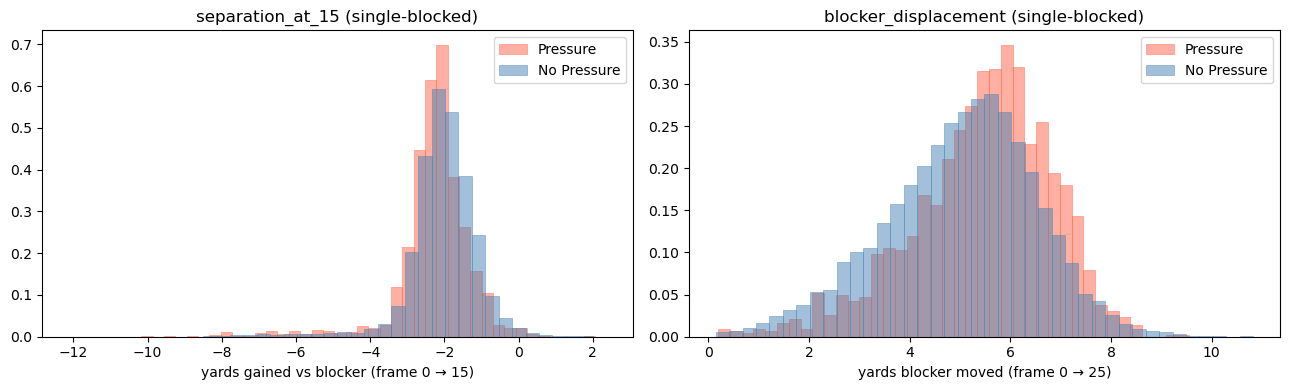

In [ ]:
# Create a visual to help identify thresholds for the single-blocked context
# separation_at_15: change in rusher to blocker distance from frame 0 to frame 15 (negative = rusher drove into blocker, positive = rusher gained separation)
# blocker_displacement: how much the blocker had to move from frame 0 to frame 25
single = metrics[metrics['blocking_context'] == 'single_blocked'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for pressure_val, label, color in [(True, 'Pressure', 'tomato'), (False, 'No Pressure', 'steelblue')]:
    subset = single[single['causedPressure'] == pressure_val]
    axes[0].hist(subset['separation_at_15'].dropna(), bins=40, alpha=0.5,
                 label=label, color=color, density=True,
                 edgecolor=color, linewidth=0.6)     # ← outline matches fill color
    axes[1].hist(subset['blocker_displacement'].dropna(), bins=40, alpha=0.5,
                 label=label, color=color, density=True,
                 edgecolor=color, linewidth=0.6)

axes[0].set_title('separation_at_15 (single-blocked)')
axes[0].set_xlabel('yards gained vs blocker (frame 0 → 15)')
axes[0].legend()

axes[1].set_title('blocker_displacement (single-blocked)')
axes[1].set_xlabel('yards blocker moved (frame 0 → 25)')
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / 'nb03_thresholds.png', dpi=150, bbox_inches='tight')   # 'nb03_thresholds.png'
plt.show()

### Chosen Thresholds

These values go directly into the NB04 win-type cascade.

| Metric | Threshold | Direction |
|---|---|---|
| `separation_at_15` | -2.0 yds | > threshold → speed win candidate |
| `blocker_displacement` | 6.5 yds | > threshold → power win candidate |

## Validation

In [36]:
print(f"Row count: {len(metrics)}")

print("\nBlocking context breakdown:")
print(metrics['blocking_context'].value_counts(), "\n")
print(metrics['blocking_context'].value_counts(normalize=True).round(3))

metric_cols = ['separation_at_15', 'separation_at_25',
               'blocker_displacement', 'rusher_dir_change', 'hip_turn_delta']

print("\nNull rates per metric:")
print(metrics[metric_cols].isnull().mean().round(3))

print("\nCorrelation with causedPressure (single-blocked plays only):")
single = metrics[metrics['blocking_context'] == 'single_blocked']
corr = single[metric_cols + ['causedPressure']].corr()['causedPressure'].drop('causedPressure')
print(corr.round(3))

Row count: 23345

Blocking context breakdown:
single_blocked    15726
double_teamed      5598
unblocked          2021
Name: blocking_context, dtype: int64 

single_blocked    0.674
double_teamed     0.240
unblocked         0.087
Name: blocking_context, dtype: float64

Null rates per metric:
separation_at_15        0.087
separation_at_25        0.088
blocker_displacement    0.088
rusher_dir_change       0.001
hip_turn_delta          0.087
dtype: float64

Correlation with causedPressure (single-blocked plays only):
separation_at_15       -0.082
separation_at_25       -0.050
blocker_displacement    0.094
rusher_dir_change      -0.043
hip_turn_delta         -0.003
Name: causedPressure, dtype: float64


## Save Output

In [27]:
metrics.to_csv(OUT_DIR / 'blocker_metrics.csv', index=False)

# print("Saved:", OUT_DIR / 'blocker_metrics.csv')
print("Shape:", metrics.shape)
print("Columns:", metrics.columns.tolist())

Shape: (23345, 14)
Columns: ['gameId', 'playId', 'nflId', 'displayName', 'position', 'teamAbbr', 'blocking_context', 'primary_blocker_nflId', 'causedPressure', 'separation_at_15', 'separation_at_25', 'blocker_displacement', 'rusher_dir_change', 'hip_turn_delta']
